# Project Submission: Amazon Sales Analysis

Complete mini-project for Excel to Python Analytics Bootcamp.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

file_path = Path("Amazon_Sales.xlsx")
if not file_path.exists():
    raise FileNotFoundError("Amazon_Sales.xlsx not found in this folder.")

df = pd.read_excel(file_path)
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

print("Dataset loaded successfully")
print("Rows, Columns:", df.shape)
df.head()

Dataset loaded successfully
Rows, Columns: (400, 12)


,Order ID,Sales,Profit,State,Category,Order Date,Product Name,Sub-Category,Customer Name,Quantity,Payment Mode,City
0,ORD-10001,78.76,-0.98,Florida,Technology,2025-04-25,Office Chair,Tables,Customer 1,2,Debit Card,Hyderabad
1,ORD-10002,729.07,-97.77,Texas,Technology,2025-03-31,Printer,Phones,Customer 2,4,Net Banking,Pune
2,ORD-10003,742.32,96.96,Arizona,Furniture,2026-06-02,Printer,Phones,Customer 3,6,UPI,Hyderabad
3,ORD-10004,727.66,185.35,California,Technology,2026-04-05,Keyboard,Tables,Customer 4,5,Net Banking,Hyderabad
4,ORD-10005,369.55,-15.65,Illinois,Technology,2025-12-15,Office Chair,Binders,Customer 5,3,Credit Card,Chennai


In [2]:
# Q2: Dataset overview
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(list(df.columns))
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
display(df.select_dtypes(include=["number"]).describe())

Rows and Columns: (400, 12)

Column Names:
['Order ID', 'Sales', 'Profit', 'State', 'Category', 'Order Date', 'Product Name', 'Sub-Category', 'Customer Name', 'Quantity', 'Payment Mode', 'City']

Data Types:
Order ID                    str
Sales                   float64
Profit                  float64
State                       str
Category                    str
Order Date       datetime64[us]
Product Name                str
Sub-Category                str
Customer Name               str
Quantity                  int64
Payment Mode                str
City                        str
dtype: object

Statistical Summary:


,Sales,Profit,Quantity
count,400.000000,400.000000,400.00000
mean,647.786525,57.262075,5.57500
std,319.492938,102.122954,2.77825
min,51.940000,-165.080000,1.00000
25%,381.280000,-13.695000,3.00000
50%,668.425000,39.935000,6.00000
75%,909.967500,126.287500,8.00000
max,1199.510000,364.660000,10.00000


In [3]:
# Q3 + Business Q1: KPI analysis
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
avg_sales = df["Sales"].mean()
avg_profit = df["Profit"].mean()
max_sales = df["Sales"].max()
min_sales = df["Sales"].min()
avg_order_value = total_sales / total_orders

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Sales: {avg_sales:,.2f}")
print(f"Average Profit: {avg_profit:,.2f}")
print(f"Maximum Sales: {max_sales:,.2f}")
print(f"Minimum Sales: {min_sales:,.2f}")
print(f"Average Order Value: {avg_order_value:,.2f}")

Total Sales: 259,114.61
Total Profit: 22,904.83
Total Orders: 400
Average Sales: 647.79
Average Profit: 57.26
Maximum Sales: 1,199.51
Minimum Sales: 51.94
Average Order Value: 647.79


In [4]:
# Q4, Q5, Q7 and business questions on states/categories
sales_by_state = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sales_by_sub_category = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

print("Highest Sales State:", sales_by_state.index[0], f"({sales_by_state.iloc[0]:,.2f})")
print("Lowest Sales State:", sales_by_state.index[-1], f"({sales_by_state.iloc[-1]:,.2f})")
print("Highest Revenue Category:", sales_by_category.index[0], f"({sales_by_category.iloc[0]:,.2f})")
print("Highest Revenue Sub-Category:", sales_by_sub_category.index[0], f"({sales_by_sub_category.iloc[0]:,.2f})")

print("\nTop States by Sales:")
display(sales_by_state.head(10).to_frame("Sales"))
print("\nSales by Category:")
display(sales_by_category.to_frame("Sales"))
print("\nSales by Sub-Category:")
display(sales_by_sub_category.to_frame("Sales"))

Highest Sales State: Washington (34,381.65)
Lowest Sales State: Florida (21,405.95)
Highest Revenue Category: Furniture (90,635.40)
Highest Revenue Sub-Category: Chairs (50,640.37)

Top States by Sales:


,Sales
State,
Washington,34381.65
New York,30920.23
Illinois,28957.01
Texas,25698.99
Arizona,24478.28
Colorado,24183.54
Georgia,23736.08
Ohio,23147.94
California,22204.94



Sales by Category:


,Sales
Category,
Furniture,90635.40
Technology,90562.75
Office Supplies,77916.46



Sales by Sub-Category:


,Sales
Sub-Category,
Chairs,50640.37
Phones,46065.12
Accessories,43898.31
Tables,43776.71
Storage,39172.74
Binders,35561.36


In [5]:
# Q9, Q10, Q11: customer, product and payment analysis
top_5_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)
quantity_by_product = df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False)
payment_mode_orders = df.groupby("Payment Mode")["Order ID"].nunique().sort_values(ascending=False)

print("Top 5 Customers by Sales:")
display(top_5_customers.to_frame("Sales"))
print("Top Products by Quantity Sold:")
display(quantity_by_product.head(10).to_frame("Quantity"))
print("Most Preferred Payment Mode:", payment_mode_orders.index[0], f"({payment_mode_orders.iloc[0]} orders)")
display(payment_mode_orders.to_frame("Orders"))

Top 5 Customers by Sales:


,Sales
Customer Name,
Customer 39,6328.13
Customer 8,6133.53
Customer 31,6092.90
Customer 27,6074.78
Customer 34,5962.41


Top Products by Quantity Sold:


,Quantity
Product Name,
Keyboard,282
Printer,268
Monitor,252
Notebook,243
Mouse,238
Phone,219
Office Chair,219
Desk,181
Tablet,176


Most Preferred Payment Mode: COD (94 orders)


,Orders
Payment Mode,
COD,94
Debit Card,84
Net Banking,78
UPI,74
Credit Card,70


In [6]:
# Q12, Q13 and trend checks
monthly = df.groupby(df["Order Date"].dt.to_period("M")).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_index()
monthly.index = monthly.index.astype(str)

state_category_sales = df.groupby(["State", "Category"])["Sales"].sum().reset_index()

best_sales_month = monthly["Sales"].idxmax()
best_profit_month = monthly["Profit"].idxmax()

print("Highest Sales Month:", best_sales_month, f"({monthly.loc[best_sales_month, 'Sales']:,.2f})")
print("Highest Profit Month:", best_profit_month, f"({monthly.loc[best_profit_month, 'Profit']:,.2f})")
print("\nMonthly Sales and Profit Trend:")
display(monthly)
print("\nState-Category Sales (sample):")
display(state_category_sales.sort_values("Sales", ascending=False).head(15))

Highest Sales Month: 2025-09 (19,491.34)
Highest Profit Month: 2025-01 (2,672.25)

Monthly Sales and Profit Trend:


,Sales,Profit
Order Date,,
2025-01,16585.46,2672.25
2025-02,15909.16,1046.38
2025-03,15790.61,1135.18
2025-04,15214.51,1196.83
2025-05,12660.53,882.91
2025-06,13146.65,1332.23
2025-07,11741.21,683.82
2025-08,16769.20,651.77
2025-09,19491.34,1344.91



State-Category Sales (sample):


,State,Category,Sales
28,Washington,Office Supplies,13943.38
5,California,Technology,13099.35
18,New York,Furniture,12088.38
17,Illinois,Technology,11561.49
27,Washington,Furniture,11449.93
21,Ohio,Furniture,10309.19
24,Texas,Furniture,10010.19
19,New York,Office Supplies,9952.87
14,Georgia,Technology,9547.42
0,Arizona,Furniture,9322.74


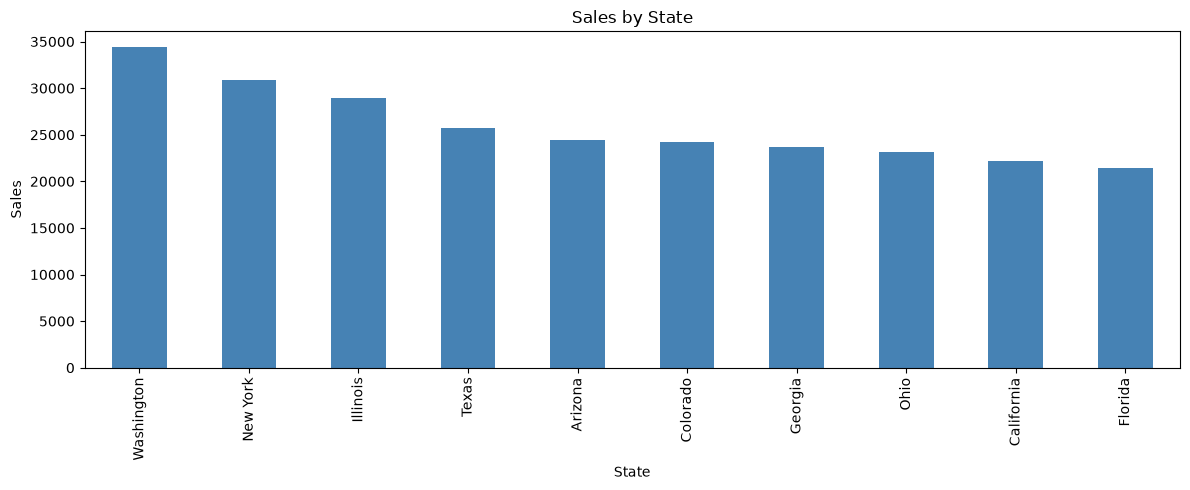

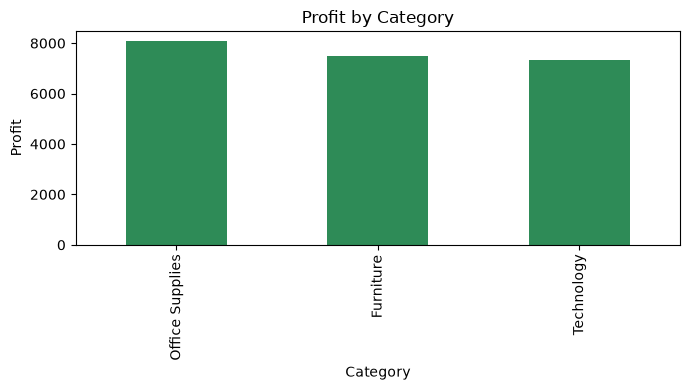

In [7]:
# Q15: Bar chart - Sales by State
sales_by_state.plot(kind="bar", figsize=(12, 5), title="Sales by State", color="steelblue")
plt.xlabel("State")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# Extra requested in brief: Column chart - Profit by Category
df.groupby("Category")["Profit"].sum().sort_values(ascending=False).plot(
    kind="bar", figsize=(7, 4), title="Profit by Category", color="seagreen"
)
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

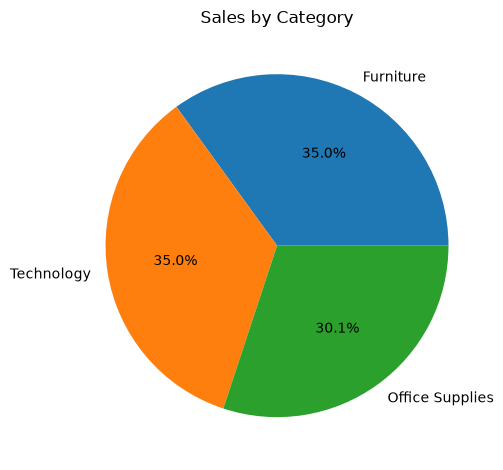

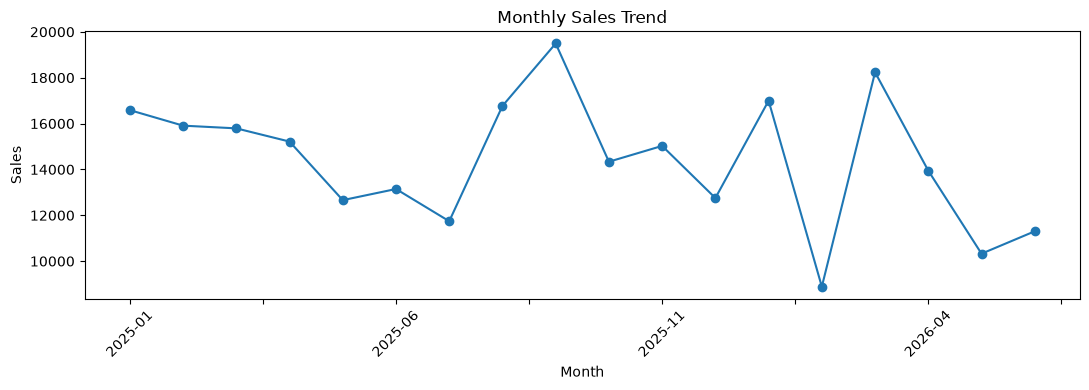

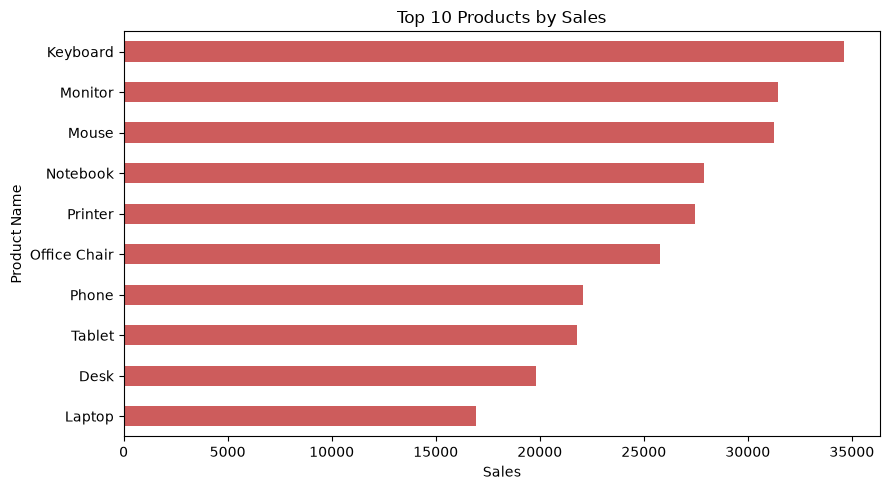

In [8]:
# Q16, Q17, Q18
sales_by_category.plot(kind="pie", autopct="%1.1f%%", title="Sales by Category")
plt.ylabel("")
plt.tight_layout()
plt.show()

monthly["Sales"].plot(kind="line", marker="o", figsize=(11, 4), title="Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df.groupby("Product Name")["Sales"].sum().nlargest(10).sort_values().plot(
    kind="barh", figsize=(9, 5), title="Top 10 Products by Sales", color="indianred"
)
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

In [9]:
# Business answers + recommendations
low_profit_high_sales = df[df["Sales"] > df["Sales"].median()].sort_values("Profit").head(10)
low_state = sales_by_state.index[-1]

print("Products with high sales but low profit (sample):")
display(low_profit_high_sales[["Product Name", "Category", "Sales", "Profit"]])
print(f"State needing sales improvement: {low_state}")

print("\nThree actionable recommendations:")
print("1. Improve pricing/discount strategy for high-sales low-profit products to protect margins.")
print("2. Run targeted promotions and faster delivery incentives in low-performing states.")
print("3. Double down on top categories/products using bundled offers and repeat-customer campaigns.")

Products with high sales but low profit (sample):


,Product Name,Category,Sales,Profit
356,Mouse,Technology,1126.20,-165.08
290,Notebook,Furniture,1154.60,-158.23
159,Desk,Furniture,1097.01,-156.13
162,Monitor,Technology,1053.24,-139.08
270,Notebook,Office Supplies,1170.85,-136.01
296,Tablet,Office Supplies,958.93,-131.24
31,Mouse,Furniture,1038.58,-118.99
37,Laptop,Technology,1055.66,-118.56
347,Notebook,Technology,1094.13,-115.18
299,Office Chair,Office Supplies,996.84,-112.77


State needing sales improvement: Florida

Three actionable recommendations:
1. Improve pricing/discount strategy for high-sales low-profit products to protect margins.
2. Run targeted promotions and faster delivery incentives in low-performing states.
3. Double down on top categories/products using bundled offers and repeat-customer campaigns.
